In [2]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti
import os
ti.init(arch=ti.cpu)  # Use 'ti' not 'tj'

# Add a test function to verify it works
@ti.kernel
def test():
    print("Taichi is working!")

test()

[Taichi] Starting on arch=x64


In [3]:
# measured parameters
k_PetG = 0.003e6
k_bluePLA = 0.026e6
k_redPLA = 0.017e6
k_organgePLA = 0.0043e6

In [4]:
# Constants
n12 = 5
n1, n2 = n12, n12

inertia = 1.0 # rotational inertia
k = k_PetG # spring stiffness
k_on = 0.0 # onsite torsional stiffness
l = 0.1 # unit length
a = 0.2*l # rotor length
amp = 0*np.pi/6 # amplitude of perturbation
drag = 0.00 # drag damping

freq = np.array([np.sqrt(k_on/inertia), np.sqrt(k*a*a/inertia)]).max()
period = 2*np.pi/freq
t_step = 100
dt = period/t_step

save_step =  1
total_step = t_step * 20

print(dt)

result_dir = None
# result_dir =  f'results_rotors/k{k}k_on{k_on}/{n1}x{n2}/'
# os.makedirs(result_dir, exist_ok=True)

0.057357372095454745


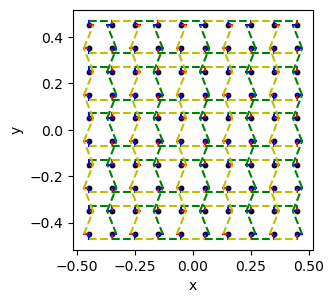

In [5]:
# Geometry
pos = np.array([[i*l-(2*n1-1)*l/2, j*l-(2*n2-1)*l/2] 
                for j in range(n2*2) 
                for i in range(n1*2)], dtype=np.float32)
theta_unit = np.array([[np.pi, -np.pi/2], [0, np.pi/2]], dtype=np.float32)
theta0 = np.array([theta_unit[j%2, i%2] 
                   for j in range(n2*2)
                   for i in range(n1*2)], dtype=np.float32)
rotors = np.array([[a, 0],[0, a]], dtype=np.float32)
def rotation_matrix_2d(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])
def pos_rotors(theta, id):
    return rotation_matrix_2d(theta) @ rotors[id]
    
point1 = np.array([pos[i] + pos_rotors(theta0[i], 0)
                   for i in range(len(pos))])
point2 = np.array([pos[i] + pos_rotors(theta0[i], 1)
                   for i in range(len(pos))])

bonds1 = np.array([[j*n1*2+i, j*n1*2+i+1]
                   for j in range(n2*2)
                   for i in range(n1*2-1)], dtype=np.int32)
bonds2 = np.array([[j*n1*2+i, (j+1)*n1*2+i]
                   for j in range(n2*2-1)
                   for i in range(n1*2)], dtype=np.int32)
bonds = np.concatenate([bonds1, bonds2], axis=0)
cross1 = np.array([[(i+1)%2, i%2]
                   for j in range(n2*2)
                   for i in range(n1*2-1)], dtype=np.int32)
cross2 = np.array([[(i)%2, (i)%2] 
                   for j in range(n2*2-1)
                   for i in range(n1*2)], dtype=np.int32)
cross = np.vstack([cross1, cross2])


ax = plt.figure(figsize=(6, 6)).add_axes([0.3, 0.3, 0.4, 0.4])
ax.scatter(pos[:, 0], pos[:, 1], s=10, c='k')
for i in range(len(pos)):
    ax.plot([pos[i, 0], point1[i, 0]], [pos[i, 1], point1[i, 1]], 'r')
    ax.plot([pos[i, 0], point2[i, 0]], [pos[i, 1], point2[i, 1]], 'b')
for i in range(len(bonds)):
    nid0, nid1 = bonds[i,0], bonds[i,1]
    cid0, cid1 = cross[i,0], cross[i,1]
    node0 = pos[nid0]+pos_rotors(theta0[nid0], cid0)
    node1 = pos[nid1]+pos_rotors(theta0[nid1], cid1)
    n01 = np.array([node0, node1])
    if i%2 == 0:
        ax.plot(n01[:,0], n01[:,1], c='y', linestyle='dashed')
    else:
        ax.plot(n01[:,0], n01[:,1], c='g', linestyle='dashed')
ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [6]:
# Predefine
N_nodes = len(pos)
N_bonds = len(bonds)
pos_ti = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)
theta0_ti = ti.field(dtype=ti.f32, shape=N_nodes)
rotors_ti = ti.Vector.field(2, dtype=ti.f32, shape=2)
bonds_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
cross_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)

pos_ti.from_numpy(pos)
theta0_ti.from_numpy(theta0)
rotors_ti.from_numpy(rotors)
bonds_ti.from_numpy(bonds)
cross_ti.from_numpy(cross)

theta_ti = ti.field(dtype=ti.f32, shape=N_nodes)
omega_ti = ti.field(dtype=ti.f32, shape=N_nodes)
torque_ti = ti.field(dtype=ti.f32, shape=N_nodes)

bond_length0_ti = ti.field(dtype=ti.f32, shape=N_bonds)
bond_length_ti = ti.field(dtype=ti.f32, shape=N_bonds)
bond_nodes_ti = ti.Vector.field(2, dtype=ti.f32, shape=(N_bonds, 2))


In [7]:
# Initialize
@ti.func
def rotation_matrix_2d_ti(theta):
    return ti.Matrix([[ti.cos(theta), -ti.sin(theta)],
                     [ti.sin(theta),  ti.cos(theta)]])
@ti.kernel
def bond_nodes():
    for i in range(N_bonds):
        nid0, nid1 = bonds_ti[i]
        pos0, pos1 = pos_ti[nid0], pos_ti[nid1]
        th0, th1 = theta_ti[nid0], theta_ti[nid1]
        cid0, cid1 = cross_ti[i]
        node0 = pos0 + rotation_matrix_2d_ti(th0) @ rotors_ti[cid0]
        node1 = pos1 + rotation_matrix_2d_ti(th1) @ rotors_ti[cid1]
        bond_nodes_ti[i,0] = node0
        bond_nodes_ti[i,1] = node1
        bond_length_ti[i] = (node1 - node0).norm()

theta_ti.copy_from(theta0_ti)
bond_nodes()
bond_length0_ti.copy_from(bond_length_ti)

@ti.kernel
def initialize():
    for i in range(N_nodes):
        theta_ti[i] = theta0_ti[i]
    omega_ti.fill(0.0)
    

@ti.func
def random(x): # [-1, 1) * x
    return x * 2 *(ti.random(dtype=ti.f32) - 0.5)
@ti.kernel
def perturbation():
    for i in range(N_nodes):
        theta_ti[i] += random(amp)

# initialize()
# perturbation()

In [8]:
# torques
@ti.kernel
def zero_torque():
    torque_ti.fill(0.0)

@ti.kernel
def nodal_torque():
    for i in range(N_bonds):
        force = k * (bond_length_ti[i] - bond_length0_ti[i])
        vec = (bond_nodes_ti[i,1] - bond_nodes_ti[i,0]).normalized()
        cid0, cid1 = cross_ti[i] 
        nid0, nid1 = bonds_ti[i]  
        th0, th1 = theta_ti[nid0], theta_ti[nid1]     
        r0 = rotation_matrix_2d_ti(th0) @ rotors_ti[cid0]
        f0 = + force * vec
        torque_ti[nid0] += r0.cross(f0)
        r1 = rotation_matrix_2d_ti(th1) @ rotors_ti[cid1]
        f1 = - force * vec
        torque_ti[nid1] += r1.cross(f1)

@ti.kernel
def nodal_onsite():
    for i in range(N_nodes):
        torque_ti[i] -= k_on * (theta_ti[i] - theta0_ti[i])
        torque_ti[i] -= drag * omega_ti[i]

# Update velocity based on forces
@ti.kernel
def update_velocity():
    for i in range(N_nodes):
        omega_ti[i] += torque_ti[i] / inertia * dt

# Update positions based on velocity
@ti.kernel
def update_position():
    for i in range(N_nodes):
        theta_ti[i] += omega_ti[i] * dt

def total_force():
    zero_torque()
    bond_nodes()
    nodal_torque()
    nodal_onsite()

def symplectic_integration():
    total_force()
    update_velocity()
    update_position()

@ti.kernel
def update_position_verlet():
    for i in range(N_nodes):
        theta_ti[i] += omega_ti[i] * dt + 0.5 * torque_ti[i] / inertia * dt**2
@ti.kernel
def update_velocity_verlet():
    for i in range(N_nodes):
        omega_ti[i] += 0.5 * torque_ti[i] / inertia * dt

def velocity_verlet_integration():
    total_force()
    update_position_verlet()
    update_velocity_verlet()
    total_force()
    update_velocity_verlet()
    

In [9]:
loading_id = 0
# loading_freq = np.sqrt(k_on/inertia)
loading_freq = np.sqrt(k*a*a/inertia)
loading_amp = np.pi/12
@ti.kernel
def loading(t: ti.i32):
    theta_ti[loading_id] = theta0_ti[loading_id] + loading_amp * ti.sin(loading_freq * t * dt)
    omega_ti[loading_id] = loading_freq * loading_amp * ti.cos(loading_freq * t * dt)

In [10]:
# update
theta_data = [theta_ti.to_numpy()]
omega_data = [omega_ti.to_numpy()]


print(dt, save_step*dt, total_step*dt)

from tqdm import tqdm
for ii in tqdm(range(total_step), desc="Simulating"):
    loading(ii)
    velocity_verlet_integration()
    # symplectic_integration()
    if ii % save_step == (save_step-1):
        theta_data.append(theta_ti.to_numpy())
        omega_data.append(omega_ti.to_numpy())

print(len(theta_data))


0.057357372095454745 0.057357372095454745 114.71474419090949


Simulating: 100%|██████████| 2000/2000 [00:09<00:00, 218.55it/s]


2001


In [11]:
# kinetic energy
N_data = len(omega_data)
time = np.array([dt*save_step*i for i in range(N_data)])
theta_time_ti = ti.field(dtype=ti.f32, shape=(N_data, N_nodes))
omega_time_ti = ti.field(dtype=ti.f32, shape=(N_data, N_nodes))
theta_time_ti.from_numpy(np.array(theta_data, dtype=np.float32))
omega_time_ti.from_numpy(np.array(omega_data, dtype=np.float32))

kinetic_ti = ti.field(dtype=ti.f32, shape=N_data)
onsite_ti = ti.field(dtype=ti.f32, shape=N_data)
@ti.kernel
def kinetic_energy():
    for i in range(N_data):
        for j in range(N_nodes):
            kinetic_ti[i] += 0.5 * inertia * omega_time_ti[i,j]**2
            onsite_ti[i] += 0.5 * k_on * (theta_time_ti[i,j]-theta0_ti[j])**2
kinetic_energy()

elongation_ti = ti.field(dtype=ti.f32, shape=(N_data, N_bonds))
@ti.kernel
def elongation():
    for j in range(N_data):
        for i in range(N_bonds):
            nid0, nid1 = bonds_ti[i]
            pos0, pos1 = pos_ti[nid0], pos_ti[nid1]
            th0, th1 = theta_time_ti[j,nid0], theta_time_ti[j,nid1]
            cid0, cid1 = cross_ti[i]
            node0 = pos0 + rotation_matrix_2d_ti(th0) @ rotors_ti[cid0]
            node1 = pos1 + rotation_matrix_2d_ti(th1) @ rotors_ti[cid1]
            bond_nodes_ti[i,0] = node0
            bond_nodes_ti[i,1] = node1
            bond_length_ti[i] = (node1 - node0).norm()
            elongation_ti[j,i] = bond_length_ti[i] - bond_length0_ti[i]
elongation()

elastic_ti = ti.field(dtype=ti.f32, shape=N_data)
@ti.kernel
def elastic_energy():
    for i in range(N_data):
        for j in range(N_bonds):
            elastic_ti[i] += 0.5 * k * elongation_ti[i,j]**2
elastic_energy()


In [12]:
# node_n
# theta = np.sin(t * omega)
# damping 


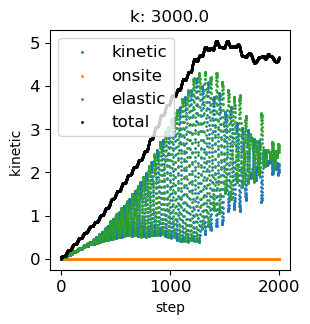

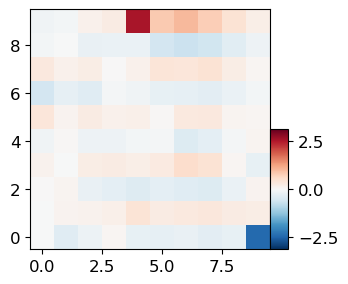

In [13]:
# figures
def kinetic_time(plt_step=1):
    kinetic_np = kinetic_ti.to_numpy()[::plt_step]
    onsite_np = onsite_ti.to_numpy()[::plt_step]
    elastic_np = elastic_ti.to_numpy()[::plt_step]

    %matplotlib inline
    plt.close('all')
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 12
    plt.rcParams['axes.labelsize'] = 10
    ax = plt.figure(figsize=(6,6)).add_axes([0.3,0.3,0.4,0.4])

    # time_np = time[::plt_step]
    # ax.scatter(time_np, kinetic_np, s=2)
    # ax.set_xlabel("time (s)")
 
    length = len(kinetic_np)
    ax.scatter(plt_step * np.arange(length), kinetic_np, s=1)
    ax.scatter(plt_step * np.arange(length), onsite_np, s=1)
    ax.scatter(plt_step * np.arange(length), elastic_np, s=1)
    ax.scatter(plt_step * np.arange(length), kinetic_np + onsite_np + elastic_np, s=1, c='k')
    ax.legend(['kinetic', 'onsite', 'elastic', 'total'])
    ax.set_xlabel("step")
    # ax.set_yscale('log')
    ax.set_ylabel("kinetic ")
    ax.set_title(f"k: {k}")
    plt.show()

kinetic_time()


# rotation displacement
pos_x = np.arange(n1*2)
pos_y = np.arange(n2*2)
delta_theta_np = (np.array(theta_data)-theta0).reshape(N_data, n2*2, n1*2)

plt.close('all')
fig = plt.figure(figsize=(6,6))
ax = fig.add_axes([0.3, 0.3, 0.4, 0.4])
cmax = abs(delta_theta_np).max()
pcolor_plot = ax.pcolormesh(pos_x, pos_y, delta_theta_np[-1], 
              cmap = 'RdBu_r', vmin=-cmax, vmax=cmax)
cbar_ax = fig.add_axes([0.7, 0.3, 0.03, 0.2])                           
cbar = fig.colorbar(pcolor_plot, ax=ax, cax=cbar_ax)
plt.show()


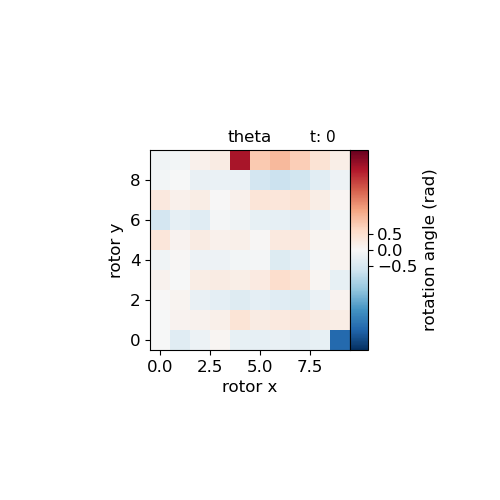

In [15]:
# mode_plot
from matplotlib.animation import FuncAnimation
# %matplotlib inline
%matplotlib widget

plt.close('all')
w, h = 5, 5
fig = plt.figure(3, figsize=(w, h))
ax = fig.add_axes([0.3, 0.3, 0.4, 0.4])     

plot = ax.pcolormesh(pos_x, pos_y, delta_theta_np[-1], 
                     cmap='RdBu_r', vmin=-cmax, vmax=cmax)
cbar_ax = fig.add_axes([0.7, 0.3, 0.035, 0.4])
cbar = fig.colorbar(plot, ax=ax, cax=cbar_ax, ticks=[-0.5, 0, 0.5])
cbar.set_label('rotation angle (rad)', fontsize=12)
text = ax.text(0.8, 1.04, 't: 0', transform=ax.transAxes, fontsize=11)
ax.set_xlabel('rotor x', fontsize=12)
ax.set_ylabel('rotor y', fontsize=12)
ax.set_title('theta', fontsize=12)

def update(frame):
    plot.set_array(delta_theta_np[frame])
    cbar.update_normal(plot)
    text.set_text(f't: {frame}')
    
ani = FuncAnimation(fig, update, frames=N_data, interval=1000/60)
plt.show()

# ani.save(f'{result_dir}/angle.mp4')


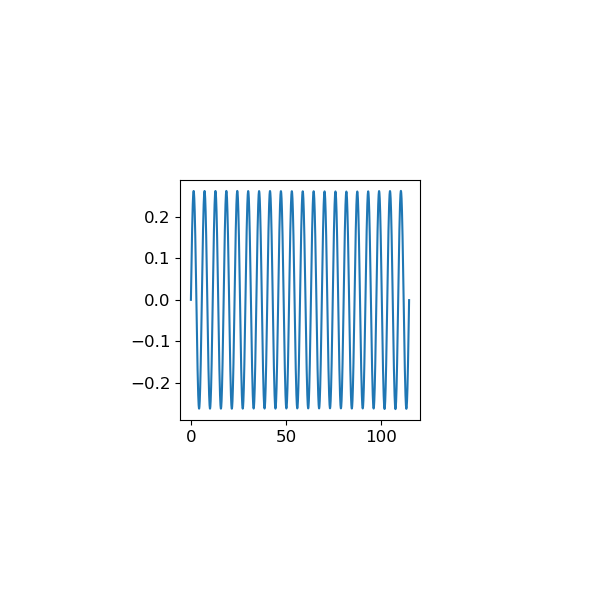

In [14]:
plt.close('all')
ax = plt.figure(figsize=(6,6)).add_axes([0.3, 0.3, 0.4, 0.4])
ax.plot(time, delta_theta_np[:,0,0])
plt.show()

In [17]:
# render using GGUI 3D
points_ti = ti.Vector.field(3, dtype=ti.f32, shape=N_bonds*2)
lines_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
points0_ti = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes*3)
lines0_ti = ti.Vector.field(2, dtype=ti.i32, shape=N_nodes*2)
@ti.kernel
def point_line():
    for i in range(N_bonds):
        points_ti[i*2][0] = bond_nodes_ti[i,0][0]
        points_ti[i*2][1] = bond_nodes_ti[i,0][1]
        points_ti[i*2][2] = 0.0
        points_ti[i*2+1][0] = bond_nodes_ti[i,1][0]
        points_ti[i*2+1][1] = bond_nodes_ti[i,1][1]
        points_ti[i*2+1][2] = 0.0
        lines_ti[i] = [i*2, i*2+1]

    for i in range(N_nodes):
        points0_ti[i*3][0] = pos_ti[i][0]
        points0_ti[i*3][1] = pos_ti[i][1]
        points0_ti[i*3][2] = 0.0
        pos0 = pos_ti[i] + rotation_matrix_2d_ti(theta_ti[i]) @ rotors_ti[0]
        pos1 = pos_ti[i] + rotation_matrix_2d_ti(theta_ti[i]) @ rotors_ti[1]
        points0_ti[i*3+1][0] = pos0[0]
        points0_ti[i*3+1][1] = pos0[1]
        points0_ti[i*3+1][2] = 0.0
        points0_ti[i*3+2][0] = pos1[0]
        points0_ti[i*3+2][1] = pos1[1]
        points0_ti[i*3+2][2] = 0.0
        lines0_ti[i*2][0] = i*3
        lines0_ti[i*2][1] = i*3+1
        lines0_ti[i*2+1][0] = i*3
        lines0_ti[i*2+1][1] = i*3+2

def video(plt_step=1, close:int=1, save:int=0):
    pos_time_np = theta_time_ti.to_numpy()[::plt_step]
    N_step = len(pos_time_np)

    window = ti.ui.Window(f'k: {k}', (600, 600), vsync=True, fps_limit=60, pos =(150,150))
    canvas = window.get_canvas()
    canvas.set_background_color((1, 1, 1))
    scene = window.get_scene()
    camera = ti.ui.Camera()
    camera.up(0, 1, 0)
    camera.position(0.1*n12*l, 0.1*n12*l, 2*2*n12*l)
    camera.lookat(0.0, 0.0, 0.0)
    gui = window.get_gui()
    pause = False
    step = 0

    if save == 1:
        close = 1
        video_manager = ti.tools.VideoManager(output_dir=result_dir, framerate=60, automatic_build=False)
    

    while window.running:
        camera.track_user_inputs(window, movement_speed=1, hold_key=ti.ui.RMB)
        scene.set_camera(camera)
        camera.lookat(0.0, 0.0, 0.0)
        scene.ambient_light((0.5, 0.5, 0.5))
        scene.point_light(pos=(1.6*a, 1.6*a, 1.6*a), color=(1, 1, 1))

        for e in window.get_events(ti.ui.PRESS):
            if e.key == ti.ui.ESCAPE:
                window.running = False
            elif e.key == ti.ui.SPACE:
                    pause = not pause
        if window.is_pressed('r'): step = 0
        
        with gui.sub_window("Lattices", 0.00, 0.00, 0.5, 0.1) as w:
                w.text(f"frmae({int(plt_step*(N_step-1))}):{int(plt_step*step)}")

        # background        
        # initial frame
        # scene.lines(vertices=nodes_ti, indices=bonds_ti, color=(0.7, 0.7, 0.7), width=2.0)
        
        # bonds
        theta_ti.from_numpy(pos_time_np[step])
        bond_nodes()
        point_line()
        scene.lines(vertices=points_ti, indices=lines_ti, color=(0.8, 0.0, 0.0), width=4.0)
        scene.lines(vertices=points0_ti, indices=lines0_ti, color=(0.0, 0.0, 0.0), width=8.0)
        
        canvas.scene(scene)
        window.show()

        if save == 1:
            img = window.get_image_buffer_as_numpy()
            video_manager.write_frame(img)
        if not pause:
            step += 1
        if step >= N_step:
            if close == 1:
                window.running = False
            pause = not pause
            step += -1
    if save == 1:
        video_manager.make_video(gif=False, mp4=True)
    
video(close=1)


: 

In [19]:
# video(save=1)

# import ffmpeg

# cwd = os.getcwd() 
# input_file = f'{cwd}/{result_dir}video.mp4'
# output_file = f'{cwd}/{result_dir}video_comp2.mp4'

# def compress_video(input_file, output_file, crf=28, preset="medium"):
#     try:
#         ffmpeg.input(input_file).output(
#             output_file,
#             vcodec="libx264",  # H.264 codec for best compatibility
#             crf=crf,           # Lower = better quality, higher = smaller file
#             preset=preset,     # Compression speed/quality trade-off
#             acodec="aac",      # Audio codec
#             audio_bitrate="128k"  # Audio bitrate
#         ).run(overwrite_output=True)
#         print(f"Compression successful: {output_file}")
#     except ffmpeg.Error as e:
#         print("Error:", e.stderr.decode())

# compress_video(input_file, output_file, crf=28, preset="fast")